# 🧪 Etapa 3: Modelagem Supervisionada

## 1. Importação dos dados processados

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

df = pd.read_csv("../data/processed/students_clean.csv")
X = df.drop(columns=["final_grade"])
y = df["final_grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 2. Definição das métricas e baseline

In [2]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

baseline = LinearRegression()
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_metrics = evaluate(y_test, baseline_pred)
baseline_metrics

{'MAE': 0.41714343631257544,
 'MSE': 0.2977417979865925,
 'RMSE': np.float64(0.5456572165623694),
 'R2': 0.6722443540838681}

## 3. Conjunto de modelos e validação cruzada (5-fold)

In [3]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=5000),
    "DecisionTree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(kernel="rbf", C=10, gamma="scale"),
    "KNN": KNeighborsRegressor(n_neighbors=7)
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring="neg_mean_absolute_error"
    )
    cv_results.append({"Modelo": name, "MAE_CV": -scores.mean(), "Std": scores.std()})

cv_df = pd.DataFrame(cv_results).sort_values("MAE_CV")
cv_df

,Modelo,MAE_CV,Std
6,SVR,0.396427,0.023449
5,GradientBoosting,0.399507,0.016448
1,Ridge,0.431354,0.019777
2,Lasso,0.431428,0.017627
0,LinearRegression,0.432091,0.020738
4,RandomForest,0.432292,0.014087
7,KNN,0.509951,0.020343
3,DecisionTree,0.568525,0.010158


## 4. Treino final, métricas completas e comparação

In [4]:
metrics_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    metrics = evaluate(y_test, preds)
    metrics["Modelo"] = name
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list).set_index("Modelo").sort_values("MAE")
metrics_df

,MAE,MSE,RMSE,R2
Modelo,,,,
GradientBoosting,0.389461,0.261021,0.510902,0.712667
SVR,0.390063,0.268454,0.518125,0.704485
RandomForest,0.415163,0.305672,0.552876,0.663515
LinearRegression,0.417143,0.297742,0.545657,0.672244
Lasso,0.420287,0.298907,0.546724,0.670962
Ridge,0.420348,0.300545,0.548220,0.669159
KNN,0.505799,0.416710,0.645531,0.541284
DecisionTree,0.513313,0.462690,0.680213,0.490669


## 5. Visualizações: comparação de MAE e Predito vs Real

C:\Users\ryanc\AppData\Local\Temp\ipykernel_2000\3781504942.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


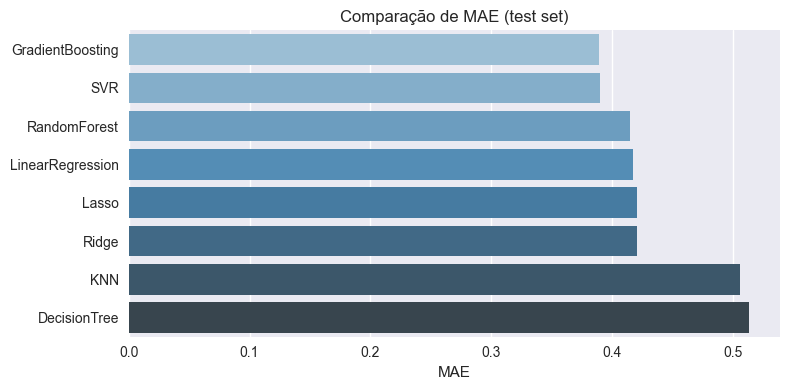

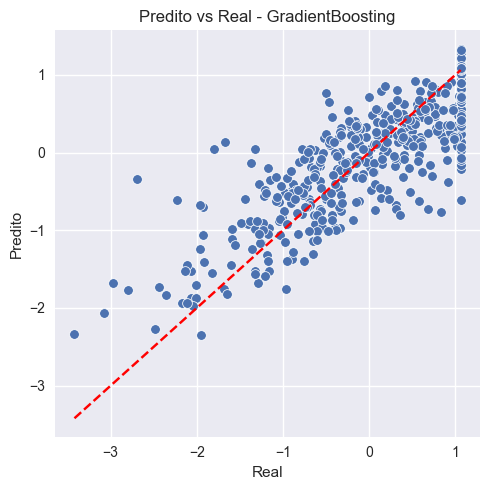

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=metrics_df.reset_index(),
    y="Modelo",
    x="MAE",
    palette="Blues_d",
    order=metrics_df.reset_index().sort_values("MAE")["Modelo"]
)
plt.title("Comparação de MAE (test set)")
plt.xlabel("MAE")
plt.ylabel("")
plt.tight_layout()
plt.show()

best_model_name = metrics_df.index[0]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Real")
plt.ylabel("Predito")
plt.title(f"Predito vs Real - {best_model_name}")
plt.tight_layout()
plt.show()

## 6. Análise de erros e resíduos

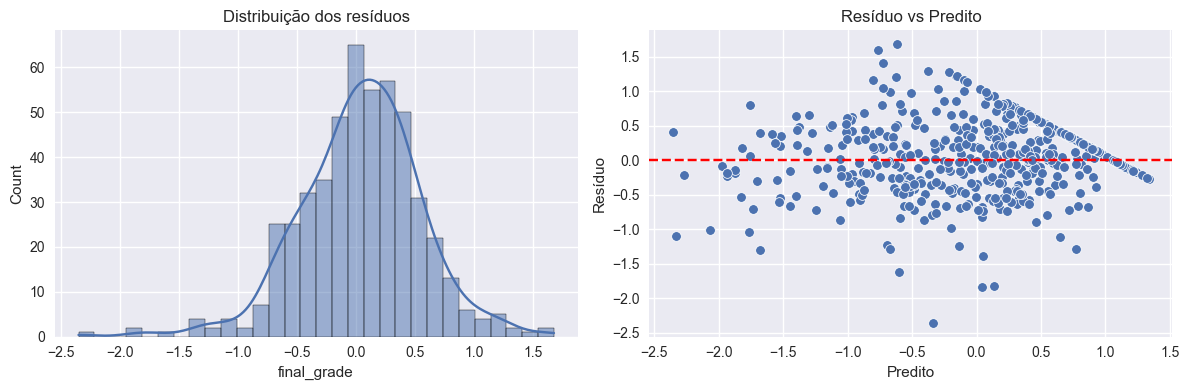

In [6]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(residuals, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribuição dos resíduos")

sns.scatterplot(x=y_pred_best, y=residuals, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Resíduo")
axes[1].set_title("Resíduo vs Predito")

plt.tight_layout()
plt.show()

## 7. Importância de features (modelos tree-based)

C:\Users\ryanc\AppData\Local\Temp\ipykernel_2000\1905542884.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="Greens_d")


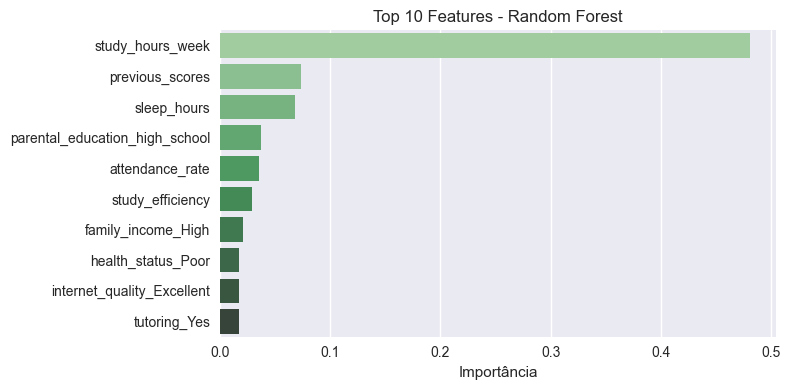

In [7]:
tree_model = RandomForestRegressor(n_estimators=300, random_state=42)
tree_model.fit(X_train, y_train)

importances = pd.Series(
    tree_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)[:10]

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette="Greens_d")
plt.title("Top 10 Features - Random Forest")
plt.xlabel("Importância")
plt.ylabel("")
plt.tight_layout()
plt.show()